In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
import numpy as np
import pickle

In [ ]:
#pip install --upgrade Pillow #In case it's needed
!pip install pillow

In [2]:
import multiprocessing as mp 
from multiprocessing import Pool

In [3]:
sys.path.append('./tools')

In [4]:
from some_tools import *

## Estructura de Carpetas

In [5]:
MiM_path = Path(os.getcwd()).parent

In [6]:
DIR = sys.path.append(MiM_path/'data')
BASE = Path(MiM_path/'data')

In [34]:
datasets = os.listdir(BASE/'raw-data/')

In [39]:
# Estructura de carpetas a crear
folders = {str(BASE.as_posix()):
            {'/images':dict.fromkeys(['/'+dataset for dataset in datasets])
            ,'/labels': None
            ,'/splits':None
            ,'/reports':None}
        }

In [40]:
# Crea la estructura de carpetas si aún no estan creadas.
create_folders_scheme(folders)

Already exists: "c:/Users/marielmoran/Desktop/MiM/data/images/DDR-dataset".
Already exists: "c:/Users/marielmoran/Desktop/MiM/data/images/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-".
Already exists: "c:/Users/marielmoran/Desktop/MiM/data/images/HRF - Quality".
Already exists: "c:/Users/marielmoran/Desktop/MiM/data/images/Kaggle".
Already exists: "c:/Users/marielmoran/Desktop/MiM/data/images/RETINOGRAFIAS - Calidad".
Already exists: "c:/Users/marielmoran/Desktop/MiM/data/labels".
Already exists: "c:/Users/marielmoran/Desktop/MiM/data/splits".
Created successfully: "c:/Users/marielmoran/Desktop/MiM/data/reports".


## Archivo Label
Se crea un archivo pickle para cada dataset, donde se guardará el nombre de archivo y la etiqueta. 

### HRF

In [27]:
raw_HRF = Path(BASE/'raw-data/HRF - Quality')

In [29]:
labels_HRF = pd.DataFrame()
labels_HRF['filename'] = os.listdir(raw_HRF)
labels_HRF['file_path'] = labels_HRF.filename.apply(lambda x: raw_HRF/x)
labels_HRF['label'] = labels_HRF.filename.apply(lambda x: int('bad' in x)) 

In [31]:
labels_HRF.to_pickle(BASE/'labels/HRF.pkl')

### DDR

In [32]:
raw_DDR = Path(BASE/'raw-data/DDR-dataset/DR_grading')

In [33]:
labels_DDR_train = pd.read_csv(raw_DDR/'train.txt',sep=' ', header = None)
labels_DDR_train.columns = ['filename','label']
labels_DDR_train['file_path'] = labels_DDR_train.filename.apply(lambda x: raw_DDR/'train'/x)

labels_DDR_val = pd.read_csv(raw_DDR/'valid.txt',sep=' ', header = None)
labels_DDR_val.columns = ['filename','label']
labels_DDR_val['file_path'] = labels_DDR_val.filename.apply(lambda x: raw_DDR/'valid'/x)


labels_DDR_test = pd.read_csv(raw_DDR/'test.txt',sep=' ', header = None)
labels_DDR_test.columns = ['filename','label']
labels_DDR_test['file_path'] = labels_DDR_test.filename.apply(lambda x: raw_DDR/'test'/x)


labels_DDR = pd.concat([labels_DDR_train, labels_DDR_val, labels_DDR_test],ignore_index=True)

In [34]:
labels_DDR['label'] = labels_DDR['label'].apply(lambda x: 1 if x == 5 else 0)

In [35]:
labels_DDR = labels_DDR.reindex(columns=['filename','file_path','label'])

In [36]:
labels_DDR.to_pickle(BASE/'labels/DDR.pkl')

### Retinografía

In [7]:
raw_Retinografia = Path(BASE/'raw-data/RETINOGRAFIAS - Calidad')

In [8]:
labels_Retin_Buena = pd.DataFrame()
labels_Retin_Buena['filename'] = os.listdir(raw_Retinografia/'Buena Calidad') 
labels_Retin_Buena['file_path'] = labels_Retin_Buena.filename.apply(lambda x: raw_Retinografia/'Buena Calidad'/x)
labels_Retin_Buena['label'] = 0

In [9]:
Retin_Regular_filename = []
for i in os.listdir(raw_Retinografia/'Regular Calidad'):
    for j in os.listdir(raw_Retinografia/'Regular Calidad'/i):
        filename = j
        file_path = raw_Retinografia/'Regular Calidad'/i/j
        Retin_Regular_filename.append((filename,file_path))

In [10]:
labels_Retin_Regular = pd.DataFrame(Retin_Regular_filename, columns = ['filename','file_path'])
labels_Retin_Regular['label'] = 1

In [11]:
Retin_Mala_filename = []
for i in os.listdir(raw_Retinografia/'Mala Calidad'):
    for j in os.listdir(raw_Retinografia/'Mala Calidad'/i):
        filename = j
        file_path = raw_Retinografia/'Mala Calidad'/i/j
        Retin_Mala_filename.append((filename,file_path))

In [12]:
labels_Retin_Mala = pd.DataFrame(Retin_Mala_filename, columns = ['filename','file_path'])
labels_Retin_Mala['label'] = 2

In [13]:
labels_Retinografia = pd.concat([labels_Retin_Buena, labels_Retin_Mala, labels_Retin_Regular],ignore_index=True)

**Este dataset tiene 5 imágenes duplicadas. Tres de ellas con mismo label por lo que se elimina uno. Las otras dos imágenes repetidas tienen diferente label (buena calidad, regular calidad). En estas últimas se elimina el registro con label de buena calidad, asumiendo que la foto tiene algún defecto que merece ser reconocido por el modelo.**

In [14]:
duplicados = labels_Retinografia[labels_Retinografia.duplicated(subset='filename')]
labels_Retinografia[labels_Retinografia.filename.isin(duplicados.filename)].sort_values(by='filename')

,filename,file_path,label
79,108.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2
101,108.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2
56,110.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2
104,110.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2
26,145.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,0
161,145.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,1
32,152.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,0
143,152.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,1
73,76.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2
134,76.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2


In [15]:
labels_Retinografia = labels_Retinografia.drop_duplicates(subset='filename',keep='last')

In [16]:
labels_Retinografia[labels_Retinografia.filename.isin(duplicados.filename)].sort_values(by='filename')

,filename,file_path,label
101,108.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2
104,110.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2
161,145.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,1
143,152.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,1
134,76.jpg,c:\Users\marielmoran\Desktop\MiM\data\raw-data...,2


In [17]:
labels_Retinografia.to_pickle(BASE/'labels/Retinografia.pkl')

### Kaggle

In [18]:
raw_kaggle = Path(BASE/'raw-data/Kaggle')

In [19]:
# ZHOU
labels_Zhou_train = pd.read_csv(raw_kaggle/'Zhou_train.csv',sep=',', header = 0)
labels_Zhou_val = pd.read_csv(raw_kaggle/'Zhou_val.csv',sep=',', header = 0)
labels_Zhou_test = pd.read_csv(raw_kaggle/'Zhou_test.csv',sep=',', header = 0)

In [20]:
labels_kaggle_zhou = pd.concat([labels_Zhou_train,labels_Zhou_val,labels_Zhou_test],ignore_index=True)

In [21]:
labels_kaggle_zhou.columns = ['filename','label']
labels_kaggle_zhou['filename'] = labels_kaggle_zhou.filename + '.png'
labels_kaggle_zhou['file_path'] = labels_kaggle_zhou.filename.apply(lambda x: raw_kaggle/'images'/x)
labels_kaggle_zhou = labels_kaggle_zhou.reindex(columns=['filename','file_path','label'])

In [23]:
labels_kaggle_zhou['label'] = labels_kaggle_zhou['label'].apply(lambda x: 1 if x == 0 else 0)

In [25]:
labels_kaggle_zhou.to_pickle(BASE/'labels/Kaggle_zhou.pkl')

In [26]:
# MARCA FU
labels_Fu_train = pd.read_csv(raw_kaggle/'Fu_train.csv',sep=',', header = 0)
labels_Fu_test = pd.read_csv(raw_kaggle/'Fu_test.csv',sep=',', header = 0)

In [27]:
labels_kaggle_fu = pd.concat([labels_Fu_train,labels_Fu_test],ignore_index=True)
labels_kaggle_fu = labels_kaggle_fu[['image','quality']]

In [28]:
labels_kaggle_fu.columns = ['filename','label']
labels_kaggle_fu['filename'] = labels_kaggle_fu.filename + '.png'
labels_kaggle_fu['file_path'] = labels_kaggle_fu.filename.apply(lambda x: raw_kaggle/'images'/x)
labels_kaggle_fu = labels_kaggle_fu.reindex(columns=['filename','file_path','label'])

In [29]:
labels_kaggle_fu.to_pickle(BASE/'labels/Kaggle_fu.pkl')

### Deep Diabetic Retinopathy Image Dataset DeepDRiD

In [55]:
raw_DRiD = Path(BASE/'raw-data/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-')

In [56]:
x = pd.read_csv(raw_DRiD/'regular_fundus_images/regular-fundus-training/regular-fundus-training.csv')
labels_DRiD_train = x.loc[:,['image_path','Overall quality']]
labels_DRiD_train['filename'] = labels_DRiD_train.image_path.apply(lambda x: x.split('\\')[-1])
labels_DRiD_train = labels_DRiD_train.reindex(columns=['filename','image_path','Overall quality'])
labels_DRiD_train.columns = ['filename','file_path','label']
labels_DRiD_train['file_path'] = labels_DRiD_train.filename.apply(lambda x: raw_DRiD/'regular_fundus_images/regular-fundus-training/Images'/x.split('_')[0]/x)
labels_DRiD_train['label']=labels_DRiD_train.label+1
labels_DRiD_train.loc[labels_DRiD_train.label == 2,'label']=0

In [57]:
x = pd.read_csv(raw_DRiD/'regular_fundus_images/regular-fundus-validation/regular-fundus-validation.csv')
labels_DRiD_val = x.loc[:,['image_path','Overall quality']]
labels_DRiD_val['filename'] = labels_DRiD_val.image_path.apply(lambda x: x.split('\\')[-1])
labels_DRiD_val = labels_DRiD_val.reindex(columns=['filename','image_path','Overall quality'])
labels_DRiD_val.columns = ['filename','file_path','label']
labels_DRiD_val['file_path'] = labels_DRiD_val.filename.apply(lambda x: raw_DRiD/'regular_fundus_images/regular-fundus-validation/Images'/x.split('_')[0]/x)
labels_DRiD_val['label']=labels_DRiD_val.label+1
labels_DRiD_val.loc[labels_DRiD_val.label == 2,'label']=0

In [58]:
labels_DRiD = pd.concat([labels_DRiD_train,labels_DRiD_val],ignore_index=True)

In [59]:
labels_DRiD.to_pickle(BASE/'labels/DRiD.pkl')

## Field of view (FOV)

Calcula el FOV y recorta la imagen a su alrededor.

### HRF

In [7]:
with open(BASE/'labels/HRF.pkl','rb') as f:
    HRF = pickle.load(f)

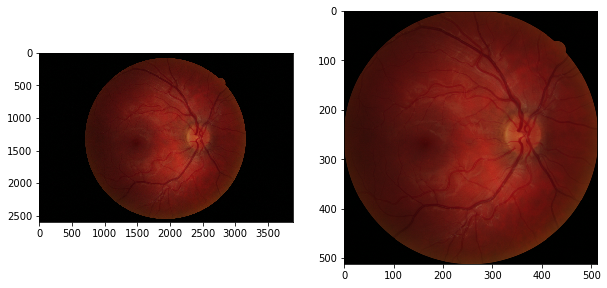

In [13]:
preprocess_and_save(HRF,BASE/'images/HRF - Quality')

### DDR

In [18]:
with open(BASE/'labels/DDR.pkl','rb') as f:
    DDR = pickle.load(f)

In [19]:
DDR_chunks = parallel_arg(DDR,BASE/'images/DDR-dataset')

In [20]:
with Pool(mp.cpu_count()) as p:
    p.starmap(preprocess_and_save,DDR_chunks)

### Retinografía

In [16]:
with open(BASE/'labels/Retinografia.pkl','rb') as f:
    retinografia = pickle.load(f)

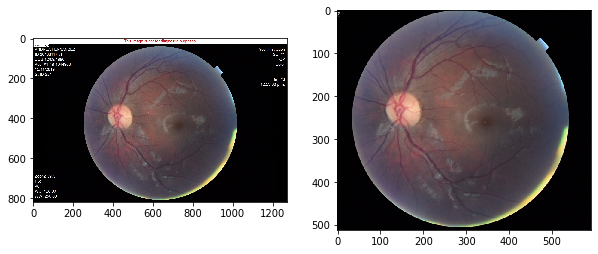

In [17]:
preprocess_and_save(retinografia,BASE/'images/RETINOGRAFIAS - Calidad',cut_text=True)

### Kaggle

In [21]:
with open(BASE/'labels/Kaggle_zhou.pkl','rb') as f:
    Zhou = pickle.load(f)

In [22]:
with open(BASE/'labels/Kaggle_fu.pkl','rb') as f:
    Fu = pickle.load(f)

In [23]:
Zhou_and_Fu = pd.concat([Zhou[['filename','file_path']],Fu[['filename','file_path']]],ignore_index=True).drop_duplicates()

In [24]:
kaggle_chunks = parallel_arg(Zhou_and_Fu,BASE/'images/Kaggle')

In [25]:
with Pool(mp.cpu_count()) as p:
    p.starmap(preprocess_and_save,kaggle_chunks)

### Deep Diabetic Retinopathy Image Dataset DeepDRiD

In [14]:
with open(BASE/'labels/DRiD.pkl','rb') as f:
    DRID = pickle.load(f)

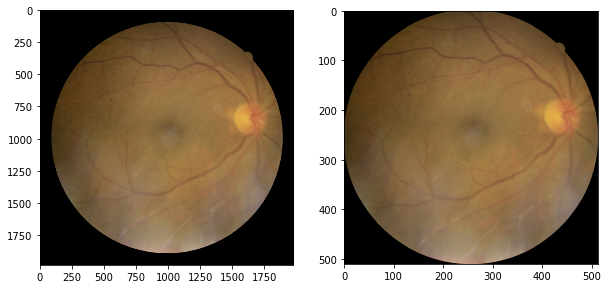

In [15]:
preprocess_and_save(DRID,BASE/'images/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-')